# Demand Dataset EDA Notebook

This notebook performs EDA on `demo.xslx`. The file has an `.xslx` extension, but it is actually tab-separated text, so it is loaded with `pd.read_csv(..., sep='\t')`.

Covered work:
- Data loading and structure checks
- Missing/null checks
- Timestamp interval and missing timestamp validation
- Demand quality checks
- Descriptive statistics
- Bivariate analysis
- Multivariate analysis
- Classification and regression overview
- Lag-feature analysis
- Final manager summary

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import HistGradientBoostingClassifier, HistGradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
BASE_DIR = Path.cwd()
DATA_FILE = BASE_DIR / 'demo.xslx'
DATA_FILE

WindowsPath('C:/Users/ShivanshShankerGupta/Desktop/Server41EDA&ML/demo.xslx')

## 1. Load Data

In [2]:
df = pd.read_csv(DATA_FILE, sep='\t')
df.head()

,datetime,date,time,block,demand,entrydatetime
0,01-01-2021 00:00,01-01-2021 00:00,00:00:00,96,884.31,49:46.9
1,01-01-2021 00:15,01-01-2021 00:00,00:15:00,1,829.94,49:46.9
2,01-01-2021 00:30,01-01-2021 00:00,00:30:00,2,817.89,49:46.9
3,01-01-2021 00:45,01-01-2021 00:00,00:45:00,3,808.27,49:46.9
4,01-01-2021 01:00,01-01-2021 00:00,01:00:00,4,796.93,49:46.9


In [3]:
print('Shape:', df.shape)
display(df.dtypes.to_frame('dtype'))
display(df.describe(include='all').T)

Shape: (173304, 6)


,dtype
datetime,str
date,str
time,str
block,int64
demand,float64
entrydatetime,str


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
datetime,173304,173304,01-01-2021 00:00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,173304,1806,01-01-2021 00:00,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
time,173304,96,00:00:00,1806,NaN,NaN,NaN,NaN,NaN,NaN,NaN
block,173304.0,NaN,NaN,NaN,48.495015,27.712828,1.0,24.0,48.0,72.0,96.0
demand,173304.0,NaN,NaN,NaN,1352.650151,277.838348,519.28,1155.150273,1355.47,1549.95,2268.14
entrydatetime,173304,15513,49:46.9,121153,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Data Preparation

In [4]:
data = df.copy()
data['datetime'] = pd.to_datetime(data['datetime'], format='%d-%m-%Y %H:%M', errors='coerce')
data['date_parsed'] = pd.to_datetime(data['date'], format='%d-%m-%Y %H:%M', errors='coerce')
data['time_parsed'] = pd.to_timedelta(data['time'], errors='coerce')
data['demand'] = pd.to_numeric(data['demand'], errors='coerce')
data = data.sort_values('datetime').reset_index(drop=True)

data['hour'] = data['datetime'].dt.hour
data['minute'] = data['datetime'].dt.minute
data['day'] = data['datetime'].dt.day
data['month'] = data['datetime'].dt.month
data['year'] = data['datetime'].dt.year
data['day_of_week'] = data['datetime'].dt.dayofweek
data['day_name'] = data['datetime'].dt.day_name()
data['day_of_year'] = data['datetime'].dt.dayofyear
data['quarter'] = data['datetime'].dt.quarter
data['is_weekend'] = (data['day_of_week'] >= 5).astype(int)

data.head()

,datetime,date,time,block,demand,entrydatetime,date_parsed,time_parsed,hour,minute,day,month,year,day_of_week,day_name,day_of_year,quarter,is_weekend
0,2021-01-01 00:00:00,01-01-2021 00:00,00:00:00,96,884.31,49:46.9,2021-01-01,0 days 00:00:00,0,0,1,1,2021,4,Friday,1,1,0
1,2021-01-01 00:15:00,01-01-2021 00:00,00:15:00,1,829.94,49:46.9,2021-01-01,0 days 00:15:00,0,15,1,1,2021,4,Friday,1,1,0
2,2021-01-01 00:30:00,01-01-2021 00:00,00:30:00,2,817.89,49:46.9,2021-01-01,0 days 00:30:00,0,30,1,1,2021,4,Friday,1,1,0
3,2021-01-01 00:45:00,01-01-2021 00:00,00:45:00,3,808.27,49:46.9,2021-01-01,0 days 00:45:00,0,45,1,1,2021,4,Friday,1,1,0
4,2021-01-01 01:00:00,01-01-2021 00:00,01:00:00,4,796.93,49:46.9,2021-01-01,0 days 01:00:00,1,0,1,1,2021,4,Friday,1,1,0


## 3. Missing Values, Nulls, and Timestamp Quality

In [5]:
null_summary = data.isna().sum().to_frame('null_count')
null_summary['null_pct'] = (data.isna().mean() * 100).round(4)
display(null_summary)

duplicate_rows = data.duplicated().sum()
duplicate_timestamps = data.duplicated(subset=['datetime']).sum()
print('Duplicate rows:', duplicate_rows)
print('Duplicate timestamps:', duplicate_timestamps)

,null_count,null_pct
datetime,0,0.0
date,0,0.0
time,0,0.0
block,0,0.0
demand,0,0.0
entrydatetime,0,0.0
date_parsed,0,0.0
time_parsed,0,0.0
hour,0,0.0
minute,0,0.0


Duplicate rows: 0
Duplicate timestamps: 0


In [6]:
intervals = data['datetime'].diff().dropna()
interval_distribution = intervals.value_counts().sort_index().to_frame('count')
display(interval_distribution)

expected_interval = pd.Timedelta(minutes=15)
full_grid = pd.date_range(data['datetime'].min(), data['datetime'].max(), freq=expected_interval)
missing_timestamps = pd.DatetimeIndex(full_grid).difference(pd.DatetimeIndex(data['datetime'].unique()))

daily_counts = data['datetime'].dt.date.value_counts().sort_index().to_frame('record_count')
incomplete_days = daily_counts[daily_counts['record_count'] != 96]

print('Most common interval:', intervals.mode().iloc[0])
print('Missing timestamps on 15-minute grid:', len(missing_timestamps))
print('Incomplete days:', len(incomplete_days))
display(incomplete_days)

,count
datetime,
0 days 00:15:00,173303


Most common interval: 0 days 00:15:00
Missing timestamps on 15-minute grid: 0
Incomplete days: 1


,record_count
datetime,
2025-12-11,24


## 4. Demand Quality and Descriptive Statistics

In [7]:
demand_checks = {
    'null_demand_rows': int(data['demand'].isna().sum()),
    'zero_demand_rows': int((data['demand'] == 0).sum()),
    'negative_demand_rows': int((data['demand'] < 0).sum()),
    'minimum_demand': data['demand'].min(),
    'maximum_demand': data['demand'].max(),
    'average_demand': data['demand'].mean(),
}
display(pd.Series(demand_checks).to_frame('value'))

q1, q3 = data['demand'].quantile([0.25, 0.75])
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = data[(data['demand'] < lower_bound) | (data['demand'] > upper_bound)]
print('IQR outlier rows:', len(outliers))
print('IQR lower/upper bounds:', round(lower_bound, 3), round(upper_bound, 3))

,value
null_demand_rows,0.000000
zero_demand_rows,0.000000
negative_demand_rows,0.000000
minimum_demand,519.280000
maximum_demand,2268.140000
average_demand,1352.650151


IQR outlier rows: 127
IQR lower/upper bounds: 562.951 2142.15


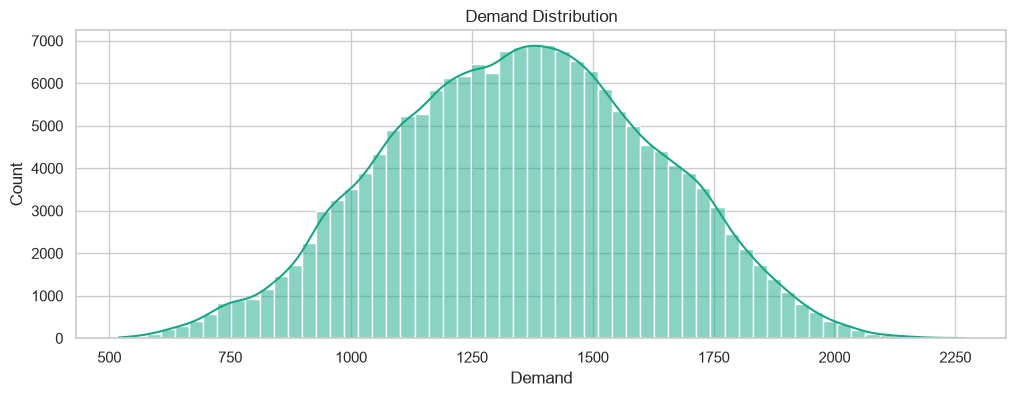

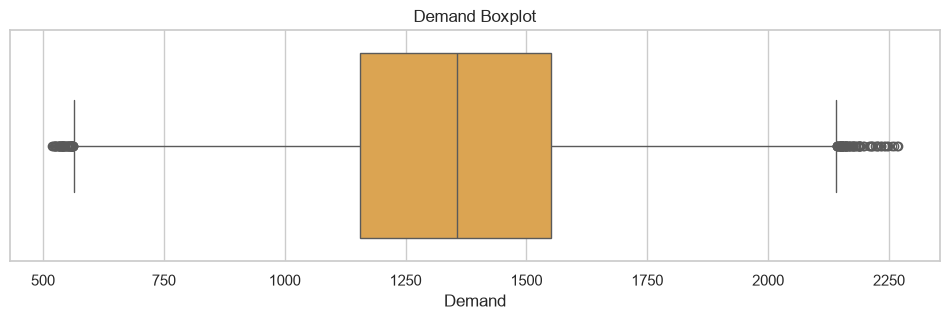

In [8]:
plt.figure(figsize=(12, 4))
sns.histplot(data['demand'], bins=60, kde=True, color='#12a886')
plt.title('Demand Distribution')
plt.xlabel('Demand')
plt.show()

plt.figure(figsize=(12, 3))
sns.boxplot(x=data['demand'], color='#f2a93b')
plt.title('Demand Boxplot')
plt.xlabel('Demand')
plt.show()

## 5. Time-Series Trend

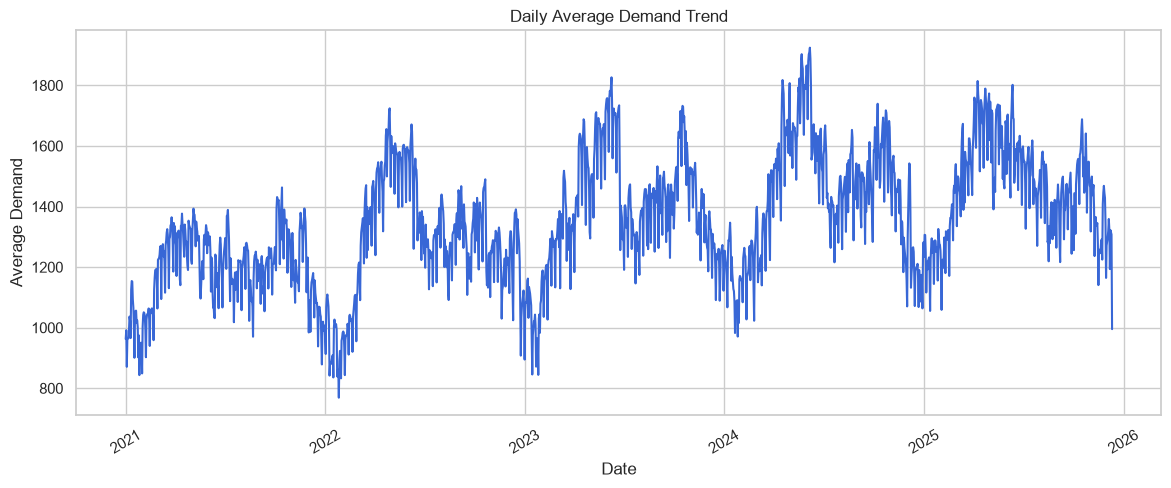

In [9]:
daily_demand = data.groupby(data['datetime'].dt.date)['demand'].mean().reset_index()
daily_demand.columns = ['date', 'avg_demand']

plt.figure(figsize=(14, 5))
sns.lineplot(data=daily_demand, x='date', y='avg_demand', color='#3867d6')
plt.title('Daily Average Demand Trend')
plt.xlabel('Date')
plt.ylabel('Average Demand')
plt.xticks(rotation=30)
plt.show()

## 6. Bivariate Analysis

Bivariate analysis checks one feature against demand at a time.

In [10]:
feature_cols = ['block', 'hour', 'minute', 'day', 'month', 'year', 'day_of_week', 'day_of_year', 'quarter', 'is_weekend']

corr_rows = []
for col in feature_cols:
    pearson = stats.pearsonr(data[col], data['demand'])
    spearman = stats.spearmanr(data[col], data['demand'])
    corr_rows.append({
        'feature': col,
        'pearson_correlation': pearson.statistic,
        'pearson_pvalue': pearson.pvalue,
        'spearman_correlation': spearman.statistic,
        'spearman_pvalue': spearman.pvalue,
    })

bivariate_corr = pd.DataFrame(corr_rows).sort_values('pearson_correlation', key=lambda s: s.abs(), ascending=False)
display(bivariate_corr)

,feature,pearson_correlation,pearson_pvalue,spearman_correlation,spearman_pvalue
1,hour,0.386919,0.000000e+00,0.388694,0.000000e+00
0,block,0.386689,0.000000e+00,0.387730,0.000000e+00
5,year,0.354379,0.000000e+00,0.353183,0.000000e+00
9,is_weekend,-0.154944,0.000000e+00,-0.159852,0.000000e+00
6,day_of_week,-0.129996,0.000000e+00,-0.135860,0.000000e+00
4,month,0.096489,0.000000e+00,0.087132,3.552219e-289
8,quarter,0.095998,0.000000e+00,0.088312,4.944234e-297
7,day_of_year,0.093103,0.000000e+00,0.085558,7.345307e-279
3,day,-0.017095,1.101741e-12,-0.015947,3.158649e-11
2,minute,0.000771,7.481045e-01,0.000643,7.890995e-01


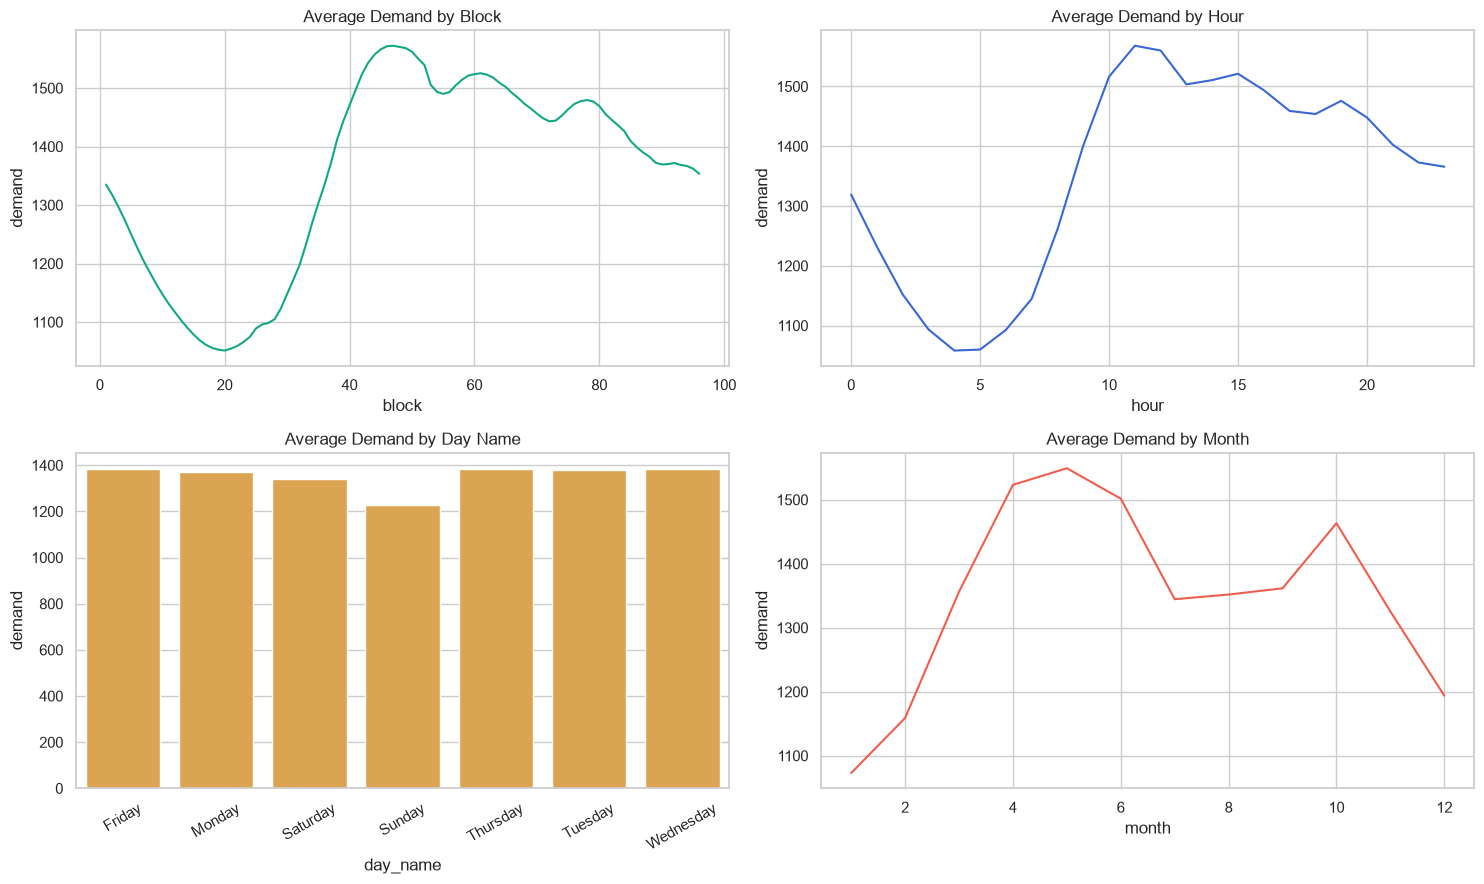

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

sns.lineplot(data=data.groupby('block', as_index=False)['demand'].mean(), x='block', y='demand', ax=axes[0, 0], color='#12a886')
axes[0, 0].set_title('Average Demand by Block')

sns.lineplot(data=data.groupby('hour', as_index=False)['demand'].mean(), x='hour', y='demand', ax=axes[0, 1], color='#3867d6')
axes[0, 1].set_title('Average Demand by Hour')

sns.barplot(data=data.groupby('day_name', as_index=False)['demand'].mean(), x='day_name', y='demand', ax=axes[1, 0], color='#f2a93b')
axes[1, 0].set_title('Average Demand by Day Name')
axes[1, 0].tick_params(axis='x', rotation=30)

sns.lineplot(data=data.groupby('month', as_index=False)['demand'].mean(), x='month', y='demand', ax=axes[1, 1], color='#f05d4f')
axes[1, 1].set_title('Average Demand by Month')

plt.tight_layout()
plt.show()

## 7. Inferential Checks

These tests check whether observed differences are statistically meaningful.

In [12]:
n = len(data)
mean_ci = stats.t.interval(0.95, n - 1, loc=data['demand'].mean(), scale=stats.sem(data['demand']))

weekday = data.loc[data['is_weekend'] == 0, 'demand']
weekend = data.loc[data['is_weekend'] == 1, 'demand']
weekday_weekend_test = stats.ttest_ind(weekday, weekend, equal_var=False)

hour_groups = [group['demand'].sample(n=min(1000, len(group)), random_state=42).values for _, group in data.groupby('hour')]
hour_anova = stats.f_oneway(*hour_groups)

print('95% CI for mean demand:', mean_ci)
print('Weekday mean:', weekday.mean())
print('Weekend mean:', weekend.mean())
print('Weekday vs weekend Welch p-value:', weekday_weekend_test.pvalue)
print('Hour vs demand ANOVA p-value:', hour_anova.pvalue)

95% CI for mean demand: (np.float64(1351.3420572431994), np.float64(1353.9582456322785))
Weekday mean: 1379.8847820295261
Weekend mean: 1284.603160177154
Weekday vs weekend Welch p-value: 0.0
Hour vs demand ANOVA p-value: 0.0


## 8. Multivariate Analysis

Multivariate analysis checks multiple features together.

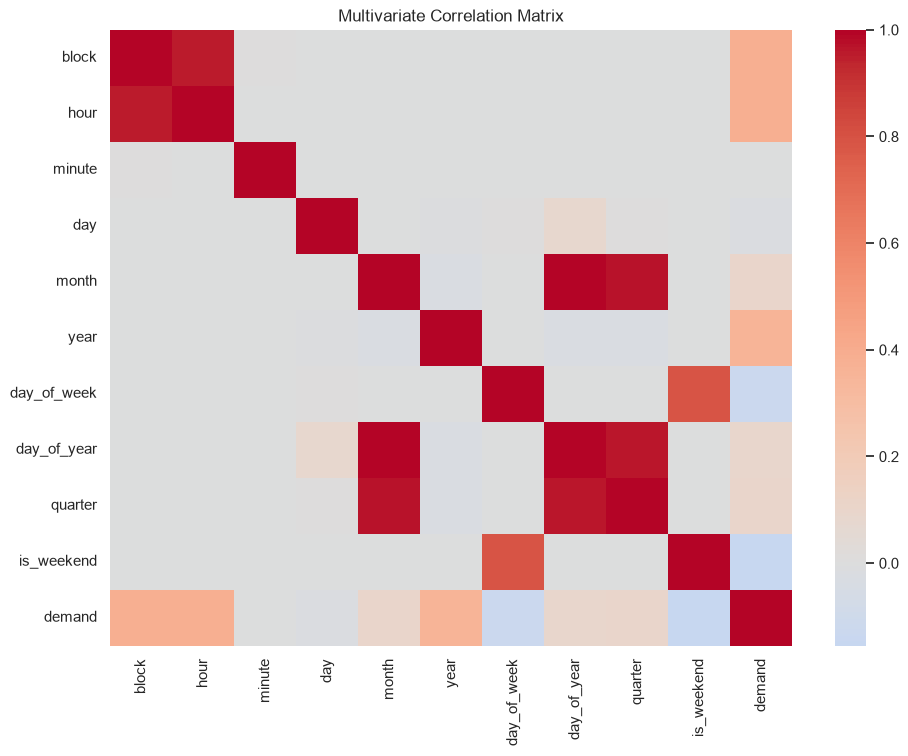

,demand
demand,1.000000
hour,0.386919
block,0.386689
year,0.354379
is_weekend,-0.154944
day_of_week,-0.129996
month,0.096489
quarter,0.095998
day_of_year,0.093103
day,-0.017095


In [13]:
corr_matrix = data[feature_cols + ['demand']].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, annot=False)
plt.title('Multivariate Correlation Matrix')
plt.show()

display(corr_matrix[['demand']].sort_values('demand', key=lambda s: s.abs(), ascending=False))

## 9. Classification and Regression Models

In [14]:
model_data = data.dropna(subset=feature_cols + ['demand']).copy()
split_idx = int(len(model_data) * 0.8)
train_df = model_data.iloc[:split_idx]
test_df = model_data.iloc[split_idx:]

x_train = train_df[feature_cols]
x_test = test_df[feature_cols]
y_train_reg = train_df['demand']
y_test_reg = test_df['demand']

low_cut, high_cut = y_train_reg.quantile([0.33, 0.66])
y_class = pd.cut(model_data['demand'], bins=[-np.inf, low_cut, high_cut, np.inf], labels=['low', 'medium', 'high'])
y_train_cls = y_class.iloc[:split_idx]
y_test_cls = y_class.iloc[split_idx:]

cls_model = HistGradientBoostingClassifier(random_state=42)
cls_model.fit(x_train, y_train_cls)
cls_pred = cls_model.predict(x_test)

reg_model = HistGradientBoostingRegressor(random_state=42, max_iter=250)
reg_model.fit(x_train, y_train_reg)
reg_pred = reg_model.predict(x_test)

print('Classification accuracy:', accuracy_score(y_test_cls, cls_pred))
print(classification_report(y_test_cls, cls_pred))
print('Regression MAE:', mean_absolute_error(y_test_reg, reg_pred))
print('Regression RMSE:', np.sqrt(mean_squared_error(y_test_reg, reg_pred)))
print('Regression R2:', r2_score(y_test_reg, reg_pred))

Classification accuracy: 0.7449871613629151
              precision    recall  f1-score   support

        high       0.87      0.82      0.85     18285
         low       0.72      0.75      0.73      6520
      medium       0.56      0.60      0.58      9856

    accuracy                           0.74     34661
   macro avg       0.72      0.72      0.72     34661
weighted avg       0.75      0.74      0.75     34661

Regression MAE: 113.97882599227475
Regression RMSE: 144.5537978409027
Regression R2: 0.6922819118696226


## 10. Lag Feature Analysis

Lag features use previous demand values to predict current/future demand.

In [15]:
lag_data = data.copy()
lag_map = {
    'lag_15min': 1,
    'lag_30min': 2,
    'lag_1hour': 4,
    'lag_2hour': 8,
    'lag_6hour': 24,
    'lag_12hour': 48,
    'lag_1day': 96,
    'lag_1week': 672,
}

for name, periods in lag_map.items():
    lag_data[name] = lag_data['demand'].shift(periods)

lag_data['rolling_mean_1hour'] = lag_data['demand'].shift(1).rolling(4).mean()
lag_data['rolling_mean_6hour'] = lag_data['demand'].shift(1).rolling(24).mean()
lag_data['rolling_mean_1day'] = lag_data['demand'].shift(1).rolling(96).mean()

lag_cols = list(lag_map.keys()) + ['rolling_mean_1hour', 'rolling_mean_6hour', 'rolling_mean_1day']
lag_model_data = lag_data.dropna(subset=feature_cols + lag_cols + ['demand']).copy()

split_idx = int(len(lag_model_data) * 0.8)
lag_train = lag_model_data.iloc[:split_idx]
lag_test = lag_model_data.iloc[split_idx:]

base_model = HistGradientBoostingRegressor(random_state=42, max_iter=250)
lag_model = HistGradientBoostingRegressor(random_state=42, max_iter=250)

base_model.fit(lag_train[feature_cols], lag_train['demand'])
lag_model.fit(lag_train[feature_cols + lag_cols], lag_train['demand'])

base_pred = base_model.predict(lag_test[feature_cols])
lag_pred = lag_model.predict(lag_test[feature_cols + lag_cols])

lag_results = pd.DataFrame({
    'model': ['Base time-feature model', 'Lag-feature model'],
    'mae': [mean_absolute_error(lag_test['demand'], base_pred), mean_absolute_error(lag_test['demand'], lag_pred)],
    'rmse': [np.sqrt(mean_squared_error(lag_test['demand'], base_pred)), np.sqrt(mean_squared_error(lag_test['demand'], lag_pred))],
    'r2': [r2_score(lag_test['demand'], base_pred), r2_score(lag_test['demand'], lag_pred)],
})
display(lag_results)

lag_correlations = lag_model_data[lag_cols + ['demand']].corr()[['demand']].drop(index='demand').sort_values('demand', key=lambda s: s.abs(), ascending=False)
display(lag_correlations)

,model,mae,rmse,r2
0,Base time-feature model,114.315828,144.857444,0.689617
1,Lag-feature model,5.328087,7.857790,0.999087


,demand
lag_15min,0.997388
lag_30min,0.991162
rolling_mean_1hour,0.987251
lag_1hour,0.968222
lag_1day,0.918889
lag_1week,0.909271
lag_2hour,0.890921
rolling_mean_6hour,0.816831
rolling_mean_1day,0.714470
lag_6hour,0.469905


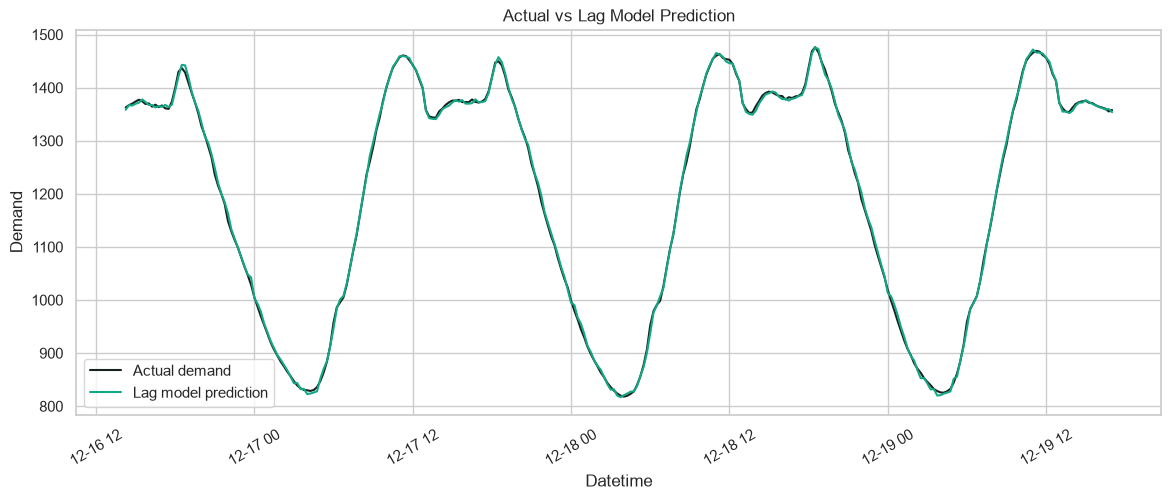

In [16]:
prediction_sample = lag_test[['datetime', 'demand']].copy().head(300)
prediction_sample['lag_prediction'] = lag_pred[:300]

plt.figure(figsize=(14, 5))
plt.plot(prediction_sample['datetime'], prediction_sample['demand'], label='Actual demand', color='#17211e')
plt.plot(prediction_sample['datetime'], prediction_sample['lag_prediction'], label='Lag model prediction', color='#12a886')
plt.title('Actual vs Lag Model Prediction')
plt.xlabel('Datetime')
plt.ylabel('Demand')
plt.legend()
plt.xticks(rotation=30)
plt.show()

## 11. Final Summary for Manager

The dataset is clean and usable for time-series demand analysis. There are no null values, duplicate timestamps, or missing timestamps. The records follow a regular 15-minute interval. The only minor issue is that the final day is incomplete because data is available only up to `05:45`.

The EDA shows that demand changes by block, hour, weekday/weekend pattern, month, year, and season. Bivariate analysis shows the strongest single relationships are with hour, block, and year. Multivariate analysis shows that block, day of year, and day of week are important demand drivers.

Classification was used to group demand into low, medium, and high categories. Regression was used to predict numeric demand. The most important improvement came from lag features. Demand from the previous 15 minutes and 30 minutes is highly correlated with current demand, so adding lag features improves forecasting performance strongly.

Overall, recent demand history is the strongest signal for future demand forecasting.